# Lab 5: Batch Gradient Descent for SLR / OLS and SLR Batch GD

## Learning Objectives

By the end of this lab, you should be able to:

- Explain Batch Gradient Descent.
- Implement Batch Gradient Descent for Simple Linear Regression.
- Compute gradients for the slope and intercept.
- Update parameters using a learning rate.
- Track Mean Squared Error during training.
- Compare Batch Gradient Descent with the SLR/OLS closed-form solution.
- Extend Gradient Descent from SLR to Multiple Linear Regression.
- Learn one weight for each feature in MLR.
- Compare SLR / OLS and SLR Batch GD using MAE, MSE, RMSE, and R².

### Lab structure

**SLR → OLS → Batch Gradient Descent → MLR → Batch Gradient Descent for MLR**

The SLR/OLS functions follow the F1 format. Data is converted to NumPy arrays once in the notebook before numerical functions are called.


## Step 1: Import Libraries and Functions

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from slr_ols_student import (
    find_mean,
    find_slope_intercept,
    predict_lr,
    mae,
    mse,
    rmse,
    r_square,
    validate_xy
)

from gradient_descent import (
    predict,
    compute_residual,
    compute_gradient,
    compute_loss,
    update_parameters,
    batch_gradient_descent
)

from mlr_gradient_descent import (
    predict_mlr,
    compute_mlr_residual,
    compute_mlr_gradient,
    compute_mlr_loss,
    update_mlr_parameters,
    batch_gradient_descent_mlr
)

print("Setup complete.")


Setup complete.


## Step 2: Download and Load the Dataset

In [2]:
file_id = "1t5mmVocO1_fGXGqRftpekRom9yxq-ML4"

if not os.path.exists("student_clean_dataset.csv"):
    import gdown
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        "student_clean_dataset.csv",
        quiet=False
    )

df = pd.read_csv("student_clean_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (300, 12)


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12


## Step 3: SLR Data Preparation

For SLR, use:

- Feature: `Assignments`
- Target: `Exam_Score`


In [3]:
X = df[["Assignments"]]
y = df["Exam_Score"]

validate_xy(X, y)

# Convert once in the notebook.
x = X["Assignments"].to_numpy(dtype=float)
y_values = y.to_numpy(dtype=float)

print("x type:", type(x))
print("y type:", type(y_values))
print("x shape:", x.shape)
print("y shape:", y_values.shape)


X shape: (300, 1)
y shape: (300,)

X data type:
Assignments    int64
dtype: object

y data type:
int64

Missing values:
X: 0
y: 0

Number of observations:
X: 300
y: 300

X and y validation successful.
x type: <class 'numpy.ndarray'>
y type: <class 'numpy.ndarray'>
x shape: (300,)
y shape: (300,)


## Step 4: Visualize the SLR Data

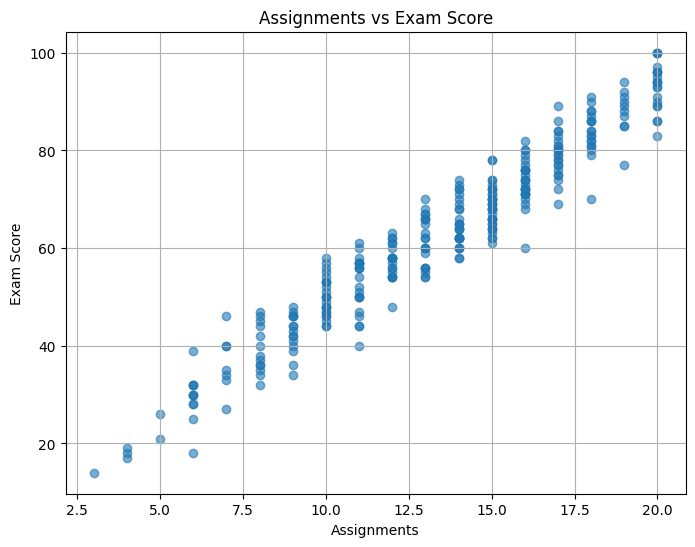

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y_values, alpha=0.6)
plt.xlabel("Assignments")
plt.ylabel("Exam Score")
plt.title("Assignments vs Exam Score")
plt.grid(True)
plt.show()


## Step 5: SLR / OLS Closed-Form Solution

The OLS solution provides the reference solution for Gradient Descent.

$$m = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}$$

$$b = \bar{y} - m\bar{x}$$


In [5]:
x_mean = find_mean(x)
y_mean = find_mean(y_values)

slr_m, slr_b = find_slope_intercept(
    x, y_values, x_mean, y_mean
)

slr_pred = predict_lr(x, slr_m, slr_b)

print("SLR / OLS slope     :", slr_m)
print("SLR / OLS intercept :", slr_b)


SLR / OLS slope     : 4.425869255751707
SLR / OLS intercept : 3.6344664842486765


## Step 6: Evaluate SLR / OLS

In [6]:
slr_mae = mae(y_values, slr_pred)
slr_mse = mse(y_values, slr_pred)
slr_rmse = rmse(y_values, slr_pred)
slr_r2 = r_square(y_values, slr_pred, y_mean)

slr_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "SLR / OLS": [slr_mae, slr_mse, slr_rmse, slr_r2]
})

display(slr_results)


,Metric,SLR / OLS
0,MAE,3.721943
1,MSE,21.395365
2,RMSE,4.625512
3,R2,0.934729


## Step 7: Batch Gradient Descent for SLR

The functions receive NumPy arrays that were converted once in Step 3.

For MSE:

$$J(m,b)=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2$$

Gradients:

$$\frac{\partial J}{\partial m}=\frac{2}{n}\sum x_i(\hat{y}_i-y_i)$$

$$\frac{\partial J}{\partial b}=\frac{2}{n}\sum(\hat{y}_i-y_i)$$

Parameter updates:

$$m \leftarrow m-\alpha\frac{\partial J}{\partial m}$$

$$b \leftarrow b-\alpha\frac{\partial J}{\partial b}$$


In [7]:
learning_rate = 0.001
epochs = 30000

initial_m = 0.0
initial_b = 0.0

bgd_m, bgd_b, loss_history = batch_gradient_descent( x, y_values, initial_m, initial_b, learning_rate, epochs)

print("Final Batch GD slope     :", bgd_m)
print("Final Batch GD intercept :", bgd_b)


Iteration     0 | Loss = 4322.8733
Iteration  1000 | Loss = 22.0323
Iteration  2000 | Loss = 21.8595
Iteration  3000 | Loss = 21.7336
Iteration  4000 | Loss = 21.6418
Iteration  5000 | Loss = 21.5750
Iteration  6000 | Loss = 21.5263
Iteration  7000 | Loss = 21.4908
Iteration  8000 | Loss = 21.4649
Iteration  9000 | Loss = 21.4460
Iteration 10000 | Loss = 21.4323
Iteration 11000 | Loss = 21.4223
Iteration 12000 | Loss = 21.4150
Iteration 13000 | Loss = 21.4097
Iteration 14000 | Loss = 21.4058
Iteration 15000 | Loss = 21.4030
Iteration 16000 | Loss = 21.4009
Iteration 17000 | Loss = 21.3994
Iteration 18000 | Loss = 21.3983
Iteration 19000 | Loss = 21.3975
Iteration 20000 | Loss = 21.3969
Iteration 21000 | Loss = 21.3965
Iteration 22000 | Loss = 21.3962
Iteration 23000 | Loss = 21.3960
Iteration 24000 | Loss = 21.3958
Iteration 25000 | Loss = 21.3957
Iteration 26000 | Loss = 21.3956
Iteration 27000 | Loss = 21.3955
Iteration 28000 | Loss = 21.3955
Iteration 29000 | Loss = 21.3955
Final Ba

## Step 8: Evaluate SLR Batch Gradient Descent

In [8]:
bgd_pred = predict(x, bgd_m, bgd_b)

bgd_mae = mae(y_values, bgd_pred)
bgd_mse = mse(y_values, bgd_pred)
bgd_rmse = rmse(y_values, bgd_pred)
bgd_r2 = r_square(y_values, bgd_pred, y_mean)

bgd_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Batch GD": [bgd_mae, bgd_mse, bgd_rmse, bgd_r2]
})

display(bgd_results)


,Metric,Batch GD
0,MAE,3.721564
1,MSE,21.395431
2,RMSE,4.625520
3,R2,0.934728


## Step 9: Compare SLR / OLS and Batch Gradient Descent

In [9]:
slr_gd_comparison = pd.DataFrame({
    "Quantity": ["Slope", "Intercept", "MAE", "MSE", "RMSE", "R2"],
    "SLR / OLS": [slr_m, slr_b, slr_mae, slr_mse, slr_rmse, slr_r2],
    "Batch GD": [bgd_m, bgd_b, bgd_mae, bgd_mse, bgd_rmse, bgd_r2]
})

display(slr_gd_comparison)

print("Absolute slope difference:",
      abs(slr_m - bgd_m))

print("Absolute intercept difference:",
      abs(slr_b - bgd_b))


,Quantity,SLR / OLS,Batch GD
0,Slope,4.425869,4.427839
1,Intercept,3.634466,3.605680
2,MAE,3.721943,3.721564
3,MSE,21.395365,21.395431
4,RMSE,4.625512,4.625520
5,R2,0.934729,0.934728


Absolute slope difference: 0.0019694598876203173
Absolute intercept difference: 0.02878604543471397


## Step 10: Plot Batch GD Convergence

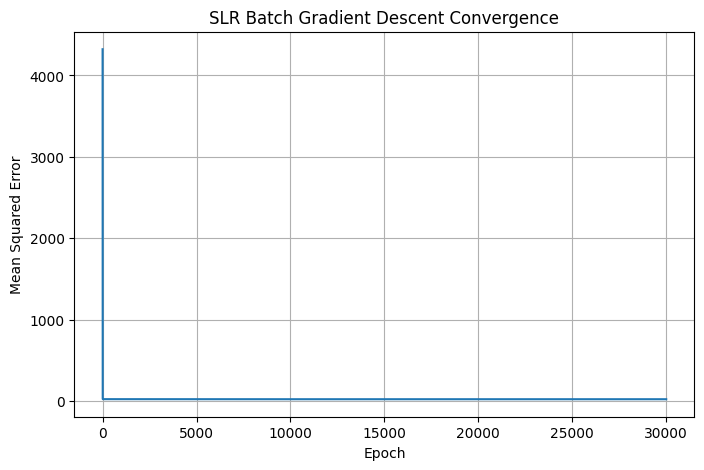

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SLR Batch Gradient Descent Convergence")
plt.grid(True)
plt.show()


## Step 11: Plot SLR / OLS and Batch GD Lines

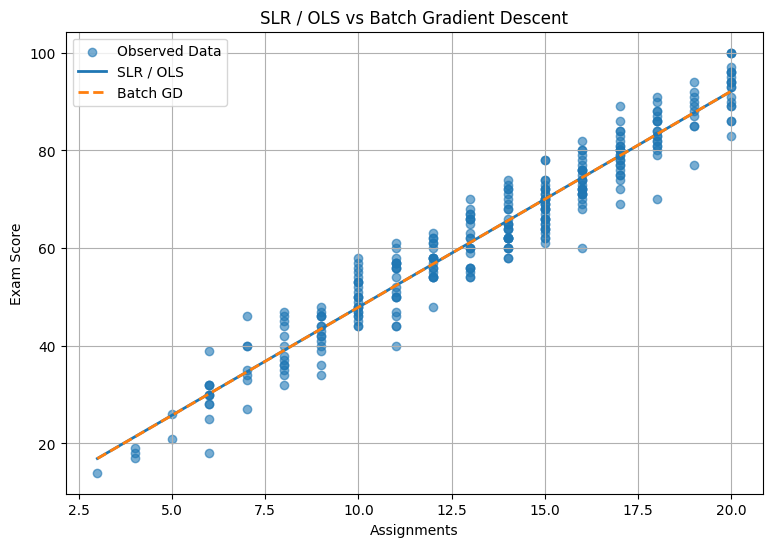

In [11]:
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

slr_line = predict_lr(x_sorted, slr_m, slr_b)
bgd_line = predict(x_sorted, bgd_m, bgd_b)

plt.figure(figsize=(9, 6))
plt.scatter(x, y_values, alpha=0.6, label="Observed Data")
plt.plot(x_sorted, slr_line, linewidth=2, label="SLR / OLS")
plt.plot(x_sorted, bgd_line, linewidth=2, linestyle="--", label="Batch GD")
plt.xlabel("Assignments")
plt.ylabel("Exam Score")
plt.title("SLR / OLS vs Batch Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()


# Core Lab Conclusion

The core experiment compares **SLR / OLS with SLR / Batch Gradient Descent** using the same feature and target.

The MLR Batch Gradient Descent section that follows is an **extra/miscellaneous extension** and is evaluated independently.

# Part B: Extra / Miscellaneous — MLR with Batch Gradient Descent

This section is an extension of the main SLR experiment. It is **not part of the SLR/OLS vs Batch Gradient Descent comparison**.

SLR remains the core experiment. Here we extend the Batch Gradient Descent idea to Multiple Linear Regression (MLR).

SLR uses one feature. MLR uses multiple features:

$$\hat{y}=b+w_1x_1+w_2x_2+...+w_px_p$$

For this extra section, use the four numeric predictors specified in M1:

- `Study_Hours`
- `Attendance`
- `Assignments`
- `Age`

Target: `Exam_Score`.

## Step 12: Select MLR Features

In [12]:
#TODO
mlr_features = ["Study_Hours", "Attendance", "Assignments","Age"]

X_mlr = df[mlr_features]
y_mlr = df["Exam_Score"]

validate_xy(X_mlr, y_mlr)

display(X_mlr.head())


X shape: (300, 4)
y shape: (300,)

X data type:
Study_Hours    int64
Attendance     int64
Assignments    int64
Age            int64
dtype: object

y data type:
int64

Missing values:
X: 0
y: 0

Number of observations:
X: 300
y: 300

X and y validation successful.


,Study_Hours,Attendance,Assignments,Age
0,3,98,12,18
1,1,81,11,20
2,3,76,9,19
3,5,100,10,19
4,5,68,13,18


## Step 13: Convert MLR Data Once

The conversion is intentionally done here, in the notebook.

All MLR numerical functions below assume `X_mlr_values` and `y_mlr_values` are already NumPy arrays.


In [13]:
#TODO
X_mlr_values = X_mlr.to_numpy(dtype=float)
y_mlr_values = y_mlr.to_numpy(dtype=float)

print("X_mlr type:", type(X_mlr_values))
print("y_mlr type:", type(y_mlr_values))
print("X_mlr shape:", X_mlr_values.shape)
print("y_mlr shape:", y_mlr_values.shape)


X_mlr type: <class 'numpy.ndarray'>
y_mlr type: <class 'numpy.ndarray'>
X_mlr shape: (300, 4)
y_mlr shape: (300,)


## Step 14: Initialize MLR Parameters

If there are `p` features, the design matrix `H` contains:

- one column of ones for the intercept
- `p` feature columns

Therefore, the parameter vector contains `p + 1` values.


In [14]:
#TODO
n_features = X_mlr_values.shape[1] + 1

initial_weights = np.zeros(n_features)

learning_rate_mlr = 0.00001
epochs_mlr = 10000

print("Number of MLR parameters:", n_features)
print("Initial weights:", initial_weights)


Number of MLR parameters: 5
Initial weights: [0. 0. 0. 0. 0.]


## Step 15: Batch Gradient Descent for MLR

For MLR, the intercept and all feature weights are stored together in one parameter vector.
The design matrix `H` is formed by adding a column of ones to `X`.

$$\nabla J = \frac{2}{n}H^T(\hat{y}-y)$$


In [15]:
mlr_weights, mlr_loss_history = batch_gradient_descent_mlr(
    X_mlr_values,
    y_mlr_values,
    initial_weights,
    learning_rate_mlr,
    epochs_mlr
)

print("\nFinal MLR parameters:")
for feature, weight in zip(["Intercept"] + mlr_features, mlr_weights):
    print(f"{feature:20s}: {weight}")


Iteration     0 | Loss = 4322.8733
Iteration  1000 | Loss = 210.8865
Iteration  2000 | Loss = 142.9092
Iteration  3000 | Loss = 98.5406
Iteration  4000 | Loss = 69.5257
Iteration  5000 | Loss = 50.5009
Iteration  6000 | Loss = 37.9806
Iteration  7000 | Loss = 29.6996
Iteration  8000 | Loss = 24.1850
Iteration  9000 | Loss = 20.4791

Final MLR parameters:
Intercept           : 0.006695026508101273
Study_Hours         : 1.554915050410818
Attendance          : 0.14966629275146165
Assignments         : 3.013056410183009
Age                 : 0.12495073585258062


## Step 16: MLR Predictions and Evaluation

In [16]:
mlr_pred = predict_mlr(
    X_mlr_values,
    mlr_weights
)

mlr_y_mean = find_mean(y_mlr_values)

mlr_mae = mae(y_mlr_values, mlr_pred)
mlr_mse = mse(y_mlr_values, mlr_pred)
mlr_rmse = rmse(y_mlr_values, mlr_pred)
mlr_r2 = r_square(y_mlr_values, mlr_pred, mlr_y_mean)

mlr_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "MLR Batch GD": [mlr_mae, mlr_mse, mlr_rmse, mlr_r2]
})

display(mlr_results)


,Metric,MLR Batch GD
0,MAE,3.418111
1,MSE,17.958746
2,RMSE,4.237776
3,R2,0.945213


## Step 17: Inspect MLR Coefficients

In [17]:
mlr_coefficients = pd.DataFrame({
    "Parameter": ["Intercept"] + mlr_features,
    "Coefficient": mlr_weights
})

display(mlr_coefficients)


,Parameter,Coefficient
0,Intercept,0.006695
1,Study_Hours,1.554915
2,Attendance,0.149666
3,Assignments,3.013056
4,Age,0.124951


## Step 18: Plot MLR Convergence

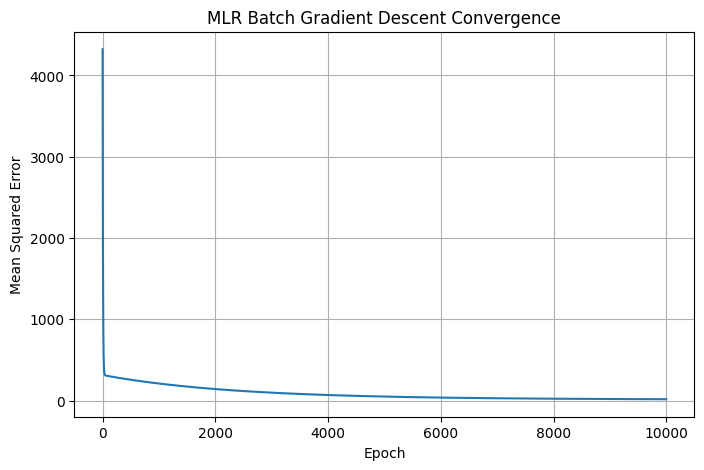

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(mlr_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MLR Batch Gradient Descent Convergence")
plt.grid(True)
plt.show()


# Final Checklist

- [ ] Loaded the student dataset.
- [ ] Validated the Pandas feature and target data.
- [ ] Converted SLR `X` and `y` to NumPy arrays once in the notebook.
- [ ] Calculated SLR/OLS slope and intercept.
- [ ] Evaluated SLR/OLS.
- [ ] Implemented Batch Gradient Descent for SLR.
- [ ] Compared SLR/OLS with Batch GD.
- [ ] Plotted the SLR Batch GD loss curve.
- [ ] Plotted the two SLR regression lines.
- [ ] Selected the four MLR features from M1.
- [ ] Converted MLR data to NumPy arrays once in the notebook.
- [ ] Implemented Batch Gradient Descent for multiple features.
- [ ] Examined MLR coefficients.
- [ ] Evaluated MLR.
- [ ] Plotted MLR convergence.
- [ ] Compared SLR / OLS and SLR Batch GD.
- [ ] Completed the analysis questions.
